## First Steps

the data can be found at `/groups/hephy/mlearning/CaloRegression/training/` and it contains 4 files:

- `test_piplus.hdf5` and `train_piplus.hdf5` contains shower data in which the incident energy was uniformly distributed
- `test_piplus_log.hdf5` and `train_piplus_log.hdf5` contains shower data in which the incident energy was log-uniformly distributed

the names 'train' and 'test' refer to the later use. 

First, we will familiarize ourselves with the dataset. 


In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
import argparse
import os
import torch
import torch.nn.functional as F



path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'

In [2]:
# load hdf5, check content and its shape

my_file = h5py.File(path_to_data+'train_piplus.hdf5', 'r')

for key in my_file:
    print(key)
    print(my_file[key][:].shape)

energy
(70000, 1)
layer_0
(70000, 3, 96)
layer_1
(70000, 12, 12)
layer_2
(70000, 12, 6)
layer_3
(70000, 3, 96)
layer_4
(70000, 12, 12)
layer_5
(70000, 12, 6)
overflow
(70000, 6)


First visualizations (For some inspiration see https://gitlab.com/claudius-krause/caloflow/-/blob/master/plot_calo.py):

- Histogram of $E_{inc}$ (key 'energy' above)
- Histogram of $E_{tot}$ (sum of all deposited energy in all layers)
- Histrograms of $E_i$ (sum of all deposited energy per layer)
- Visualization of a single shower

todo: logscale, density= true

Second: train KDE on layer energies (include $E_{inc}$ as additional dimension), see https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html
todo: 100000 sample size 

Third: set up classifier for evaluation (see https://gitlab.com/claudius-krause/caloflow/-/blob/master/classify.py)

Minimum Incident Energy (E_inc): 1.0001724157455327
Maximum Incident Energy (E_inc): 99.99933068110775


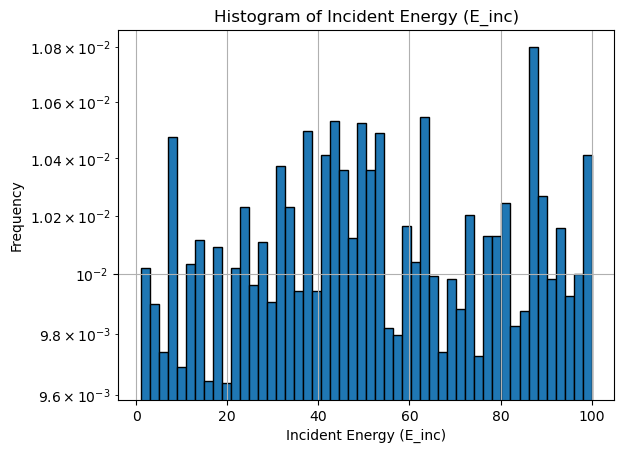

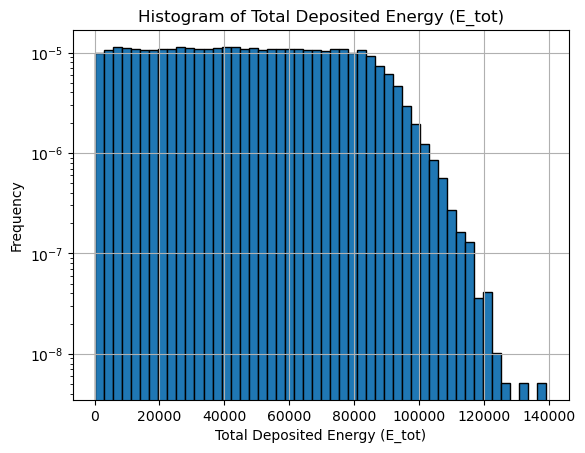

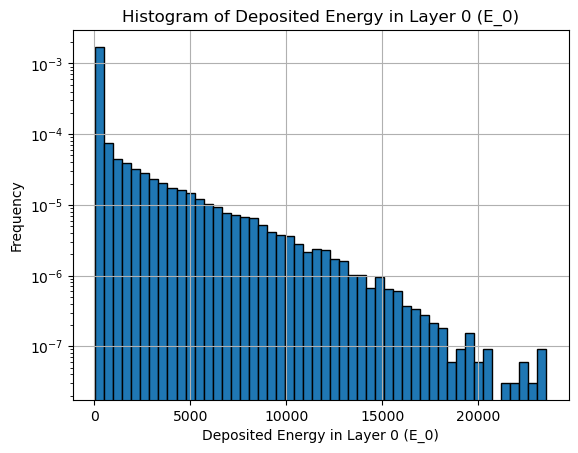

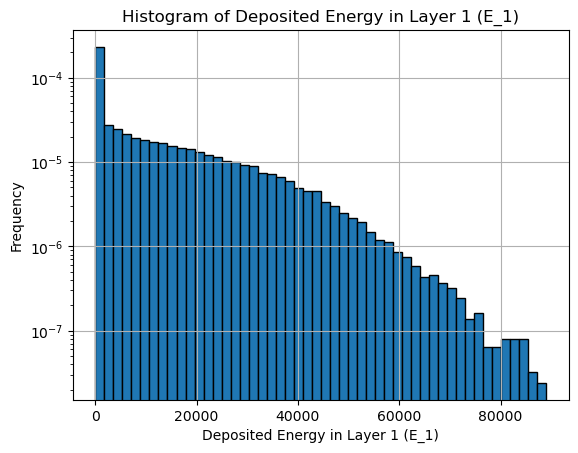

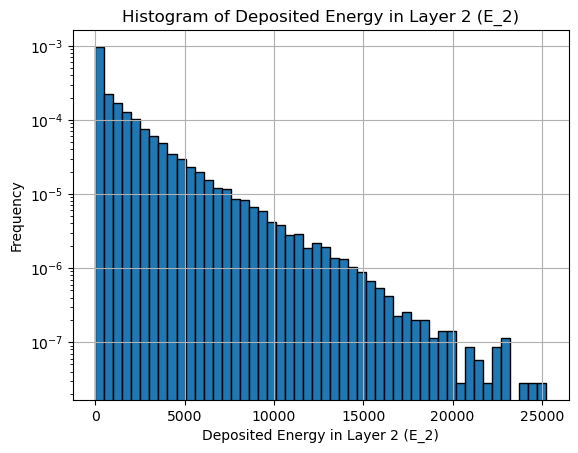

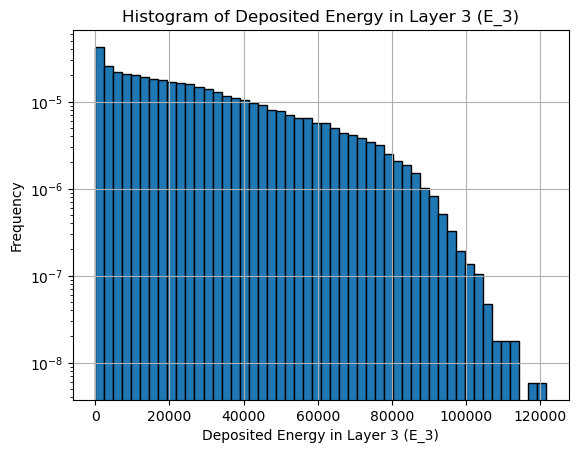

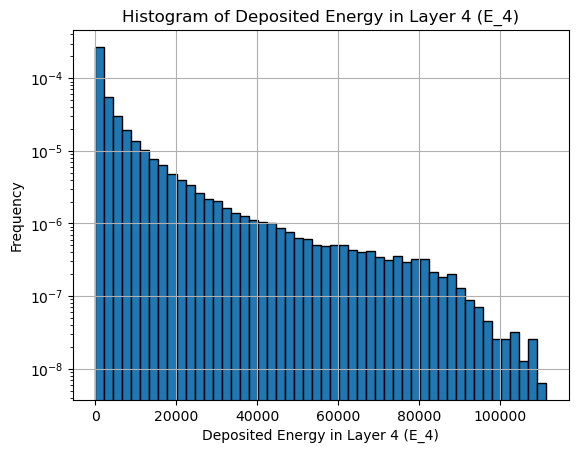

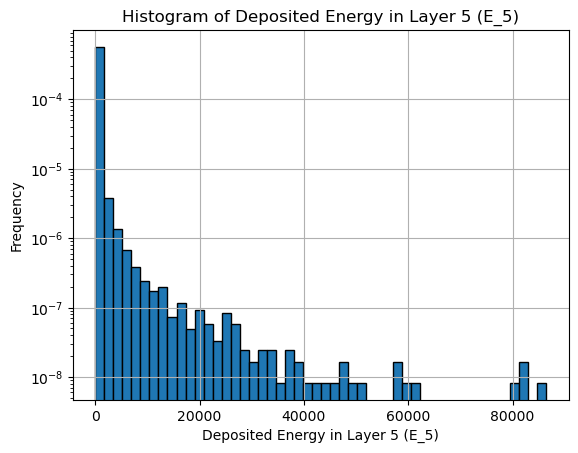

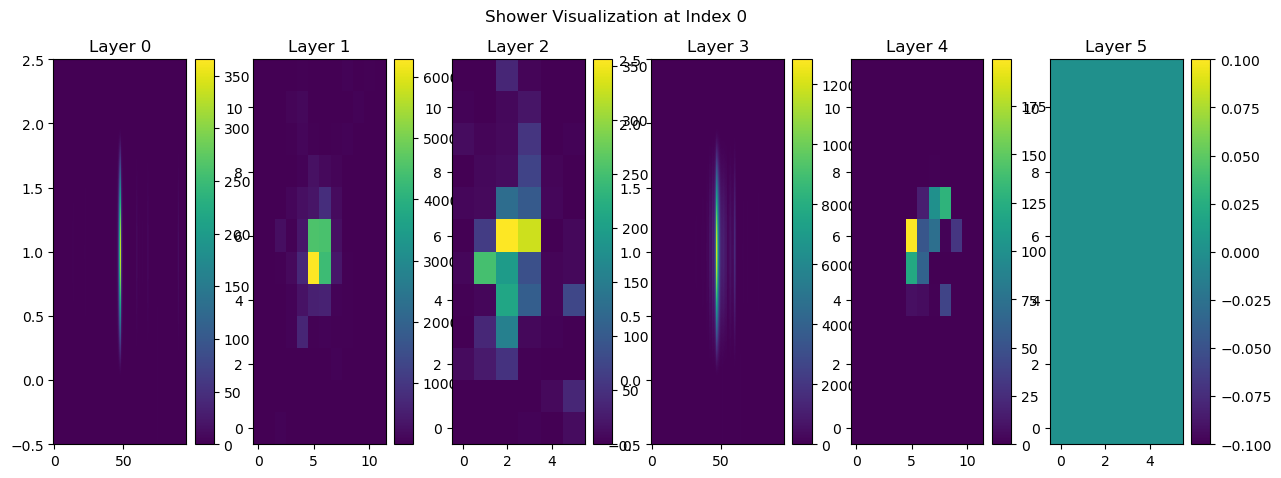

In [3]:
path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data+'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]

# Print minimum and maximum energy
min_energy = energy.min()
max_energy = energy.max()
print(f"Minimum Incident Energy (E_inc): {min_energy}")
print(f"Maximum Incident Energy (E_inc): {max_energy}")

plt.figure()
plt.hist(energy, bins=50, edgecolor='k', density=True, log=True)
plt.xlabel('Incident Energy (E_inc)')
plt.ylabel('Frequency')
plt.title('Histogram of Incident Energy (E_inc)')
plt.grid(True)
plt.show()

# 2. Histogram of E_tot (sum of all deposited energy in all layers)
E_tot = np.sum([layer.sum(axis=(1, 2)) for layer in layers], axis=0)
plt.figure()
plt.hist(E_tot, bins=50, edgecolor='k', density=True, log=True)
plt.xlabel('Total Deposited Energy (E_tot)')
plt.ylabel('Frequency')
plt.title('Histogram of Total Deposited Energy (E_tot)')
plt.grid(True)
plt.show()

# 3. Histograms of E_i (sum of all deposited energy per layer)
for i, layer in enumerate(layers):
    E_i = layer.sum(axis=(1, 2))
    plt.figure()
    plt.hist(E_i, bins=50, edgecolor='k', density=True, log=True)
    plt.xlabel(f'Deposited Energy in Layer {i} (E_{i})')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Deposited Energy in Layer {i} (E_{i})')
    plt.grid(True)
    plt.show()

# 4. Visualization of a single shower
shower_index = 0
plt.figure(figsize=(15, 5))
for i, layer in enumerate(layers):
    plt.subplot(1, 6, i+1)
    plt.imshow(layer[shower_index], aspect='auto', origin='lower')
    plt.colorbar()
    plt.title(f'Layer {i}')
plt.suptitle(f'Shower Visualization at Index {shower_index}')
plt.show()

Final samples shape: (100000, 7)
Generated 100000 valid samples.


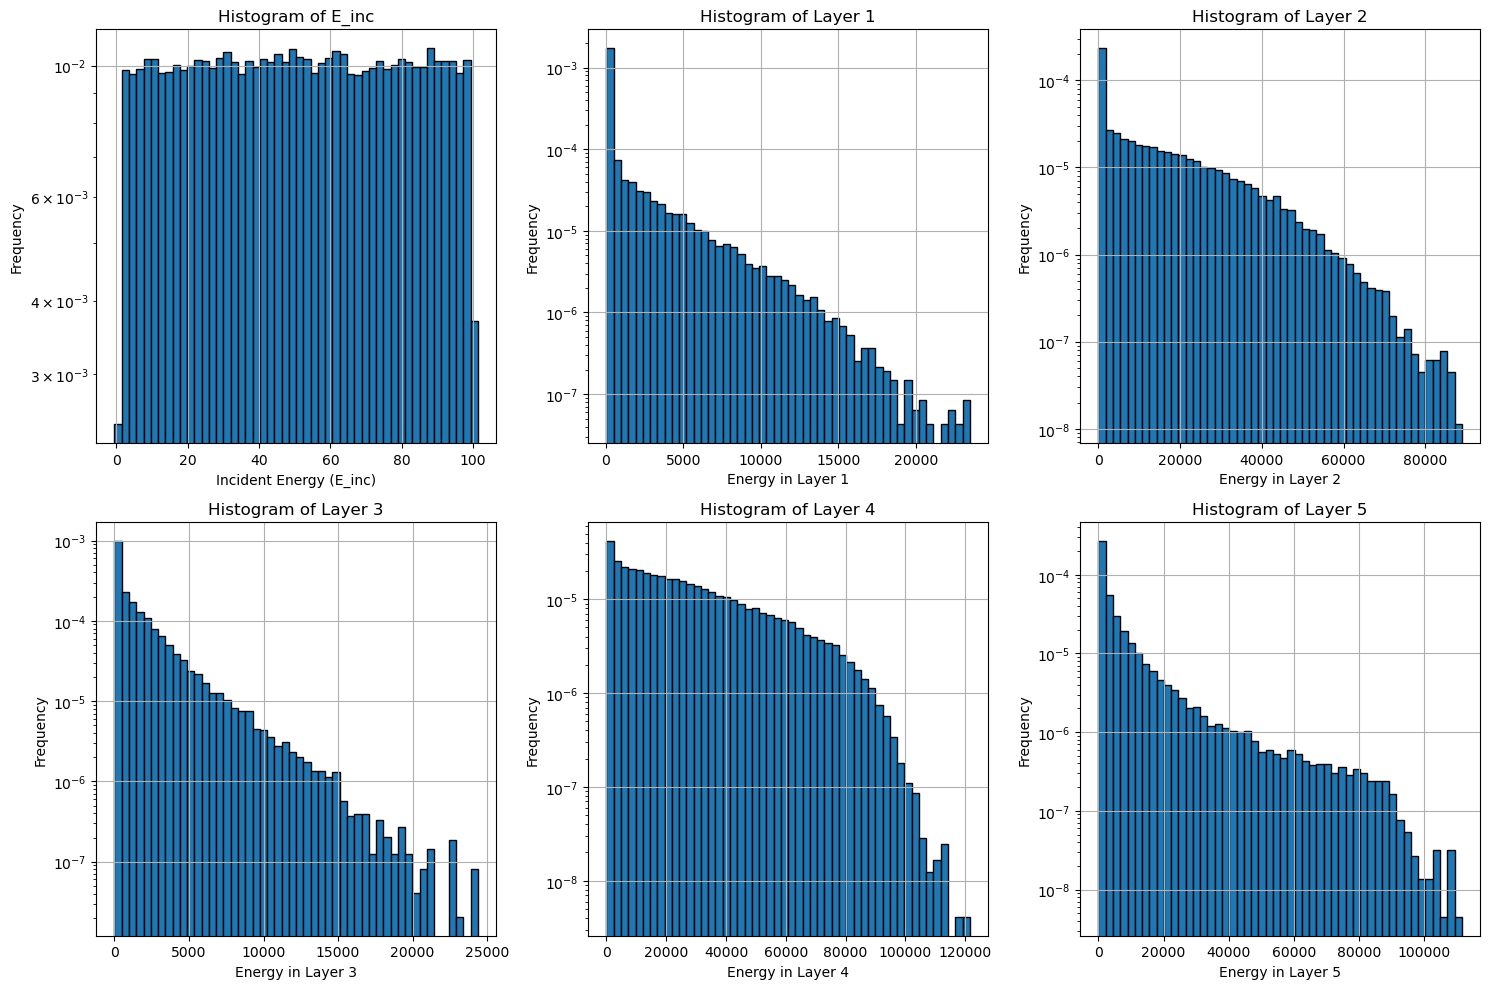

In [4]:
#TASK 2:
# deposited energy per layer
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

# incident energy and layer energies in one dataset
data = np.hstack((energy, E_layers))

# train KDE
kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde.fit(data)

# example of sampling
samples = kde.sample(n_samples=100000)

print(f"Final samples shape: {samples.shape}")
print(f"Generated {len(samples)} valid samples.")

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

for i in range(6):
    axs[i].hist(samples[:, i], bins=50, edgecolor='k',density=True, log=True)
    axs[i].set_xlabel(f'Energy in Layer {i}' if i > 0 else 'Incident Energy (E_inc)')
    axs[i].set_ylabel('Frequency')
    axs[i].set_title(f'Histogram of {"Layer " + str(i) if i > 0 else "E_inc"}')
    axs[i].grid(True)

plt.tight_layout()
plt.show()

In [5]:
#TASK 3
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import copy

#KDE SETUP
#data setup
path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data+'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]

# incident and layer energies in one dataset
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T
energy_reshaped = energy.reshape(-1, 1)
data = np.hstack((energy_reshaped, E_layers))

#train KDE
kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde.fit(data)

# generate KDE samples
n_samples = len(data)
kde_samples = kde.sample(n_samples)

# Create labels
real_labels = np.ones(n_samples)
kde_labels = np.zeros(n_samples)

# combining of real and KDE gen data
combined_data = np.vstack((data, kde_samples))
combined_labels = np.hstack((real_labels, kde_labels))

# split into trainning and test sets
X_train, X_test, y_train, y_test = train_test_split(combined_data, combined_labels, test_size=0.2, random_state=42)

#CLASSIFIER SETUP
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = torch.round(outputs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:4f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_preds = []
    all_labels = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            preds = torch.round(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_preds)
    print('Accuracy: {:.4f}, AUC (area under roc curve): {:.4f}'.format(acc, auc))
    return acc, auc

# dataloader setup
train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)
}

# Model, criterion, optimizer
input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# train & evaluate
model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
evaluate_model(model, dataloaders)

Epoch number 0/24
----------
train Loss: 50.0790 Acc: 0.4987
val Loss: 49.6607 Acc: 0.5034
Epoch number 1/24
----------
train Loss: 50.0846 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 2/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 3/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 4/24
----------
train Loss: 50.0857 Acc: 0.4991
val Loss: 49.6607 Acc: 0.5034
Epoch number 5/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 6/24
----------
train Loss: 50.0857 Acc: 0.4991
val Loss: 49.6607 Acc: 0.5034
Epoch number 7/24
----------
train Loss: 50.0839 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 8/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 9/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 10/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.503

(0.5033928571428572, 0.5)

In [6]:
"""
# === Regressive performance for KDE ===
import h5py, numpy as np, matplotlib.pyplot as plt

# load test file (the one with fixed true incident energy, e.g. 20 GeV)
test_file_path = '/groups/hephy/mlearning/CaloRegression/evaluation/piplus_20GeV.hdf5'
with h5py.File(test_file_path, 'r') as f:
    energy_test = f['energy'][:]  # just for plotting later
    layers_t = [f[f'layer_{i}'][:] for i in range(6)]

# sum up deposited energy in each layer
E_layers_test = np.array([L.sum(axis=(1, 2)) for L in layers_t]).T  # shape (M, 6)
M = E_layers_test.shape[0]

# dfine energy scan range based on training data
E_min, E_max = float(np.min(energy)), float(np.max(energy))
num_scan_points = 1000
E_candidates = np.linspace(E_min, E_max, num_scan_points)  # shape (K,)

# for every test sample, we will test all possible incident energies
# for each y (the 6 layer values), check which E gives the highest KDE log-prob
K = len(E_candidates)
E_tile = np.repeat(E_candidates[np.newaxis, :], M, axis=0).reshape(-1, 1)  # (M*K, 1)
Y_tile = np.repeat(E_layers_test, K, axis=0)                               # (M*K, 6)
joint = np.concatenate([E_tile, Y_tile], axis=1)                           # (M*K, 7)

# evaluate KDE log-probabilities for all (E, layers) combinations
logp = kde.score_samples(joint).reshape(M, K)  # (M, K)

# pick the energy candidate with the highest probability for each sample
best_idx = np.argmax(logp, axis=1)
E_inferred = E_candidates[best_idx]

# plot the inferred energy distribution
plt.figure(figsize=(10,6))
plt.hist(E_inferred, bins=100, alpha=0.7, color='skyblue', label="Inferred $E_{inc}$ (KDE)")
plt.axvline(20, color='red', linestyle='--', label='True 20 GeV')
plt.xlabel("Inferred Incident Energy (GeV)")
plt.ylabel("Counts")
plt.title("Regressive Evaluation with KDE (E_inc = 20 GeV)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
"""


'\n# === Regressive performance for KDE ===\nimport h5py, numpy as np, matplotlib.pyplot as plt\n\n# load test file (the one with fixed true incident energy, e.g. 20 GeV)\ntest_file_path = \'/groups/hephy/mlearning/CaloRegression/evaluation/piplus_20GeV.hdf5\'\nwith h5py.File(test_file_path, \'r\') as f:\n    energy_test = f[\'energy\'][:]  # just for plotting later\n    layers_t = [f[f\'layer_{i}\'][:] for i in range(6)]\n\n# sum up deposited energy in each layer\nE_layers_test = np.array([L.sum(axis=(1, 2)) for L in layers_t]).T  # shape (M, 6)\nM = E_layers_test.shape[0]\n\n# dfine energy scan range based on training data\nE_min, E_max = float(np.min(energy)), float(np.max(energy))\nnum_scan_points = 1000\nE_candidates = np.linspace(E_min, E_max, num_scan_points)  # shape (K,)\n\n# for every test sample, we will test all possible incident energies\n# for each y (the 6 layer values), check which E gives the highest KDE log-prob\nK = len(E_candidates)\nE_tile = np.repeat(E_candidates[

In [ ]:
# =========================
# KDE REGRESSION / ENERGY INFERENCE
# =========================

import time

reg_start_time = time.time()

eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))  # 10, 20, ..., 90
errors_by_energy = {}

def load_eval_layers(filepath):
    with h5py.File(filepath, 'r') as f:
        layers_eval = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers_eval = np.array(
            [layer.sum(axis=(1, 2)) for layer in layers_eval]
        ).T
    return np.clip(E_layers_eval, a_min=0.0, a_max=None)

def infer_incident_energy_kde(
    kde_model,
    layer_matrix,
    num_scan_points=1000,
    E_min=1.0,
    E_max=180.0
):
    n = layer_matrix.shape[0]
    E_candidates = np.linspace(E_min, E_max, num_scan_points).reshape(-1, 1)

    candidates = np.concatenate(
        [
            np.tile(E_candidates[None, :, :], (n, 1, 1)),
            np.tile(layer_matrix[:, None, :], (1, num_scan_points, 1))
        ],
        axis=2
    )

    candidates_log = np.log1p(np.clip(candidates, a_min=0.0, a_max=None))
    flat = candidates_log.reshape(-1, candidates_log.shape[-1])
    logp = kde_model.score_samples(flat).reshape(n, num_scan_points)

    max_idx = np.argmax(logp, axis=1)
    inferred_E = E_candidates[max_idx, 0]

    return inferred_E

# =========================
# RUN REGRESSION
# =========================
for E_true in energy_values:
    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')

    layer_tensor = load_eval_layers(file_path)
    inferred = infer_incident_energy_kde(kde, layer_tensor)

    error = inferred - E_true
    errors_by_energy[E_true] = error

    print(
        f"E_inc={E_true} GeV: "
        f"mean error = {np.mean(error):.2f}, "
        f"std = {np.std(error):.2f}"
    )

    # Histogram + metrics
    bins = 100
    counts, bin_edges = np.histogram(inferred, bins=bins, range=(1, 180))

    bin_idx = np.digitize(E_true, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, len(counts) - 1)

    ratio_true_bin = counts[bin_idx] / counts.sum()
    print(f"  True-bin ratio: {ratio_true_bin:.2%}")

    half_max = counts.max() / 2
    above = np.where(counts >= half_max)[0]
    if len(above) > 0:
        fwhm = bin_edges[above[-1] + 1] - bin_edges[above[0]]
    else:
        fwhm = 0.0

    print(f"  FWHM: {fwhm:.2f} GeV")

# =========================
# PLOT 1: Inferred energies (bunt)
# =========================
plt.figure(figsize=(12, 6))
for E_true, error in errors_by_energy.items():
    plt.hist(
        error + E_true,
        bins=100,
        range=(0, 120),
        alpha=0.5,
        label=f'{E_true} GeV'
    )
    plt.axvline(E_true, color='black', linestyle='--')

plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$ (KDE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: Error distributions (bunt)
# =========================
plt.figure(figsize=(12, 6))
for E_true, error in errors_by_energy.items():
    plt.hist(error, bins=50, alpha=0.5, label=f'{E_true} GeV')

plt.axvline(0, color='black', linestyle='--')
plt.xlabel("E_found - E_inc (GeV)")
plt.ylabel("Counts")
plt.title("Error distribution for different true energies (KDE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# REGRESSION TIME
# =========================
reg_end_time = time.time()
elapsed = reg_end_time - reg_start_time
h, rem = divmod(elapsed, 3600)
m, s = divmod(rem, 60)
print(f"Regression time: {int(h)}h {int(m)}m {s:.2f}s")


E_inc=10 GeV: mean error = -7.75, std = 0.00
  True-bin ratio: 0.00%
  FWHM: 1.79 GeV
E_inc=20 GeV: mean error = -17.75, std = 0.00
  True-bin ratio: 0.00%
  FWHM: 1.79 GeV
E_inc=30 GeV: mean error = -27.75, std = 0.00
  True-bin ratio: 0.00%
  FWHM: 1.79 GeV
E_inc=40 GeV: mean error = -37.75, std = 0.00
  True-bin ratio: 0.00%
  FWHM: 1.79 GeV
